# Лабораторная работа №5 :Тестирование качества работы моделей машинного обучения
## Цель работы: применить средства автоматизации тестирования python для автоматического тестирования качества работы модели машинного обучения на различных датасетах.
# Ход работы:

Импортируем библиотеки


In [134]:
import pytest
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

### 1. Создаем три датасета с «качественными» данными

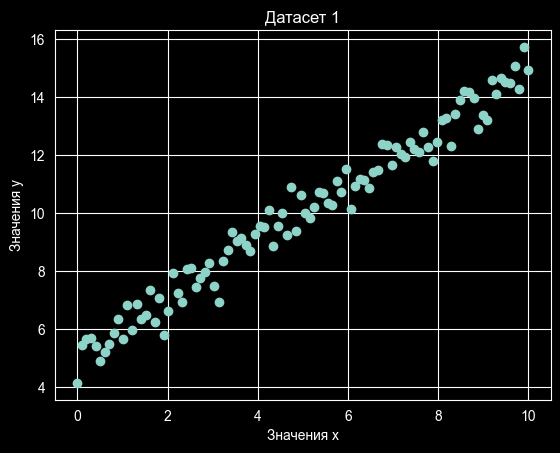

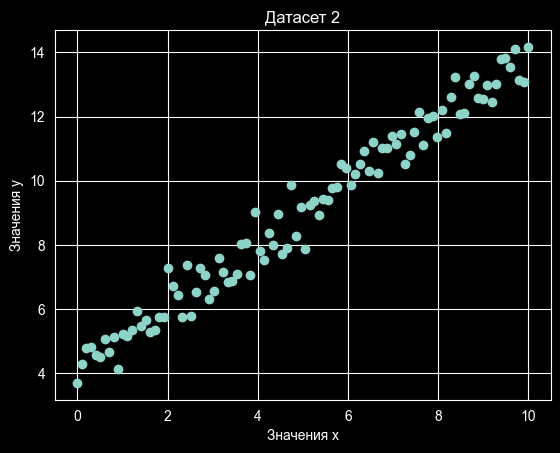

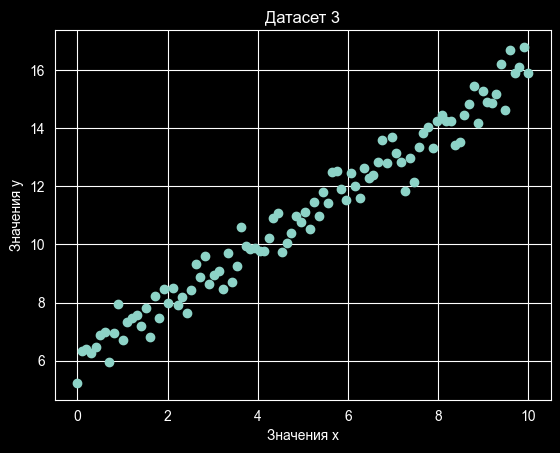

In [135]:
# 1 датасет
x1 = np.linspace(0, 10, 100).reshape(-1, 1)
y1 = x1.ravel() + np.random.randn(100)*0.5 + 5
plt.scatter(x1, y1)
plt.title('Датасет 1')
plt.xlabel('Значения x')
plt.ylabel('Значения y')
plt.show()

# 2 датасет
x2 = np.linspace(0, 10, 100).reshape(-1, 1)
y2 = x2.ravel() + np.random.randn(100)*0.5 + 4
plt.scatter(x2, y2)
plt.title('Датасет 2')
plt.xlabel('Значения x')
plt.ylabel('Значения y')
plt.show()

# 3 датасет
x3 = np.linspace(0, 10, 100).reshape(-1, 1)
y3 = x3.ravel() + np.random.randn(100)*0.5 + 6
plt.scatter(x3, y3)
plt.title('Датасет 3')
plt.xlabel('Значения x')
plt.ylabel('Значения y')
plt.show()


### 2. Обучаем модель линейной регрессии на 1 датасете

In [136]:
model = LinearRegression()

model.fit(x1, y1)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


### 3. Создаем датасет с шумом

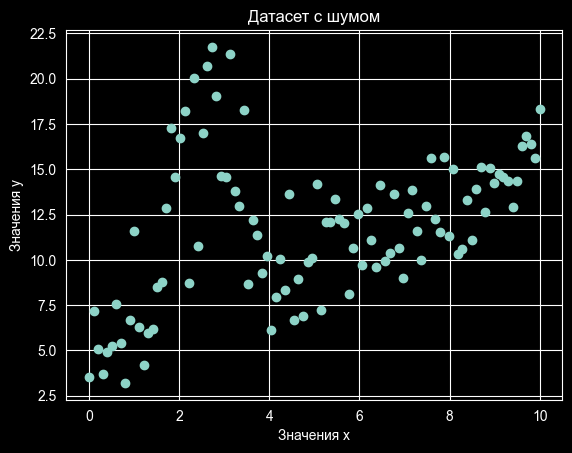

In [137]:
# Датасет с шумом
x4 = np.linspace(0, 10, 100).reshape(-1, 1)
y4 = x4.ravel() + np.random.randn(100)*2 + 5
y4[15:35] *= 2
plt.scatter(x4, y4)
plt.xlabel('Значения x')
plt.ylabel('Значения y')
plt.title('Датасет с шумом')

plt.show()

### 4. Напишем функции для тестирования

In [138]:
def test_dataset1():
    predictions = model.predict(x1)
    r2 = r2_score(y1, predictions)

    # Проверка r^2 > 0.8
    assert r2 > 0.7, f"R² = {r2:.3f} слишком низкий"




def test_dataset2():
    predictions = model.predict(x2)
    r2 = r2_score(y2, predictions)

    # Проверка r^2 > 0.7
    assert r2 > 0.7, f"R² = {r2:.3f} слишком низкий"




def test_dataset3():
    predictions = model.predict(x3)
    r2 = r2_score(y3, predictions)

    # Проверка r^2 > 0.8
    assert r2 > 0.7, f"R² = {r2:.3f} слишком низкий"



def test_dataset4():
    predictions = model.predict(x4)
    r2 = r2_score(y4, predictions)

    # Проверка r^2 > 0.8
    assert r2 > 0.7, f"R² = {r2:.3f} слишком низкий"





### 5. Запускам тесты

In [139]:
### ЗАПУСК ТЕСТОВ ###

if __name__ == "__main__":
    print("ЗАПУСК ТЕСТИРОВАНИЯ")

    # Запускаем тесты
    test_dataset1()
    test_dataset2()
    test_dataset3()
    test_dataset4()

    print(" Все тесты пройдены успешно!")

ЗАПУСК ТЕСТИРОВАНИЯ


AssertionError: R² = -0.114 слишком низкий

**Вывод:**
4 датасет не прошел проверку, R² < 0 означает, что модель на этом датасете предсказывает хуже, чем просто среднее значение, тесты правильно отработали и нашли ошибку